## Membership inference attack ( MIA ) on CIFAR-10 Trained on CNN model







## Imports and Environment Setup

This cell imports all required libraries for the experiment.  
`PyTorch` and `TorchVision` are used to define, train, and evaluate the neural network models on CIFAR-10.  
`NumPy` and `Matplotlib` are used for numerical operations and result visualization.  
`LightGBM` and `scikit-learn` are used to implement and evaluate the membership inference attack.  

The cell also creates a directory to store trained models and automatically selects the computation device (`GPU` if available, otherwise `CPU`).


In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score
import lightgbm as lgb

os.makedirs("saved_models", exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Experimental Configuration

This cell defines the main experimental parameters used throughout the study.  
`TRAIN_SIZES` specifies the different target training set sizes considered in order to analyze how membership inference vulnerability evolves with the amount of training data.  
The number of training epochs and the batch size control the optimization process of both target and shadow models.  
`NUM_SHADOW_MODELS` determines how many shadow models are trained to construct the attack dataset.  
`TARGET_TEST_SIZE` defines the number of samples used to evaluate membership on the target model.  
Finally, `NUM_CLASSES` corresponds to the number of classes in the CIFAR-10 dataset.

In [2]:
TRAIN_SIZES = [2500,5000, 10000, 15000]

epochs = 100
BATCH_SIZE = 64
NUM_SHADOW_MODELS = 100
TARGET_TEST_SIZE = 2000
NUM_CLASSES = 10

## Dataset Preparation and Preprocessing

This cell defines the preprocessing pipeline applied to the CIFAR-10 dataset.  
Images are first converted to tensors and then normalized channel-wise to have values centered around zero, which helps stabilize and accelerate neural network training.  

The CIFAR-10 dataset is then loaded and split into training and test sets.  
The training set is used to train the target and shadow models, while the test set is used to evaluate model generalization and perform membership inference attacks.

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

print("Loading CIFAR-10 dataset...")
train_dataset = datasets.CIFAR10("./data", train=True, download=True, transform=transform)
test_dataset  = datasets.CIFAR10("./data", train=False, download=True, transform=transform)

Loading CIFAR-10 dataset...
Files already downloaded and verified
Files already downloaded and verified


## Model Architecture

This cell defines the convolutional neural network architecture used for both the target and shadow models.  
The network consists of two convolutional layers followed by max-pooling operations to progressively extract spatial features from the input images.  
The extracted features are then flattened and passed through a fully connected hidden layer, followed by an output layer producing class logits for the ten CIFAR-10 classes.  

The hyperbolic tangent `(tanh)` activation function is applied after each convolutional and fully connected layer to introduce non-linearity.

In [4]:
class CIFAR10CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(16 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.tanh(self.conv1(x)))
        x = self.pool(torch.tanh(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = torch.tanh(self.fc1(x))
        return self.fc2(x)

## Training and Evaluation Procedures

This cell defines the learning rate schedule, the model training procedure, and the evaluation function.  


`The learning rate decay function` is used to gradually reduce the learning rate during training.  

`The training function` iteratively optimizes the model parameters over multiple epochs using mini-batch gradient descent and cross-entropy loss.  

`The evaluation function` runs the model in inference mode and returns the predicted class probability distributions along with the corresponding ground-truth labels, which are later used to construct the membership inference attack dataset.

In [5]:
def lr_decay(epoch):
    return 1 / (1 + epoch * 1e-7)

def train_model(model, loader, criterion, optimizer, scheduler, epochs):
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()
        print(f"      Epoch [{epoch+1:03d}/{epochs}] | Loss: {total_loss/len(loader):.4f}")

def evaluate_model(model, loader):
    model.eval()
    probs, labels = [], []

    with torch.no_grad():
        for images, y in loader:
            images = images.to(device)
            outputs = model(images)
            probs.append(F.softmax(outputs, dim=1).cpu())
            labels.append(y)

    return torch.cat(probs), torch.cat(labels)

## Membership Inference Attack Pipeline (Precise Description)

This cell implements the full experimental pipeline for membership inference attacks on CIFAR-10 models, including **target model training**, **shadow model simulation**, **attack dataset construction**, **attack model training**, and **evaluation of attack performance**.  

### 1. Target Model Preparation
- For each `train_size` in `TRAIN_SIZES`:
  - A subset of the CIFAR-10 training data of size `train_size` is randomly selected for training the **target model**.
  - A fixed-size test set (`TARGET_TEST_SIZE`) is selected to evaluate the model’s generalization.
  - If a pre-trained target model exists on disk, it is loaded; otherwise, the target model is trained using:
    - **Adam optimizer**
    - **Cross-entropy loss**
    - **Learning rate decay scheduler**
    - **`epochs` iterations**
- The trained target model is saved for reuse.

### 2. Shadow Model Simulation
- The remaining training and test data (not used for the target model) are used to train `NUM_SHADOW_MODELS` shadow models.
- Each shadow model is trained on a random subset of the remaining training data, with a corresponding test subset.
- After training, predictions (softmax probabilities) are collected on:
  - **IN (member)** → shadow model’s training data
  - **OUT (non-member)** → shadow model’s test data
- These predictions, along with their member/non-member labels and true class labels, are stored to form the **attack dataset**.

### 3. Attack Model Training
- For each class `c` in CIFAR-10:
  - Select samples of class `c` from the attack dataset.
  - Train a **LightGBM classifier** to predict membership (IN/OUT) based on the predicted probabilities.
- This results in a **per-class attack model**.

### 4. Attack Target Model
- Apply the trained attack models to the target model outputs:
  - Collect softmax probabilities of target model on its training (member) and test (non-member) sets.
  - For each class, predict membership using the corresponding attack model.
- Compute **precision for each class**, which measures how well the attack can distinguish members from non-members.
- Store per-class precisions in `all_precisions_per_size` and the **median precision** across classes in `median_per_size`.

### 5. Output
- Prints per-class precision for each `train_size`.
- Prints median precision across classes, providing a **quantitative measure of membership inference vulnerability** as a function of training set size.



In [6]:
median_per_size = {}
all_precisions_per_size = {}

for train_size in TRAIN_SIZES:

    print("\n" + "="*70)
    print(f"TRAINING SIZE = {train_size}")
    print("="*70)


    model_path = f"saved_models/target_cnn_{train_size}.pth"
    train_target = True   # set False to reload saved model

    # --------------------------------------------------------
    # TARGET DATA
    # --------------------------------------------------------

    target_train_set, remaining_train_set = random_split(
        train_dataset, [train_size, len(train_dataset) - train_size]
    )

    target_test_set, remaining_test_set = random_split(
        test_dataset, [TARGET_TEST_SIZE, len(test_dataset) - TARGET_TEST_SIZE]
    )

    target_train_loader = DataLoader(target_train_set, BATCH_SIZE, shuffle=True)
    target_test_loader  = DataLoader(target_test_set,  BATCH_SIZE, shuffle=False)

    # --------------------------------------------------------
    # TARGET MODEL
    # --------------------------------------------------------

    target_model = CIFAR10CNN().to(device)

    if not train_target and os.path.exists(model_path):
        print("Loading saved TARGET model")
        checkpoint = torch.load(model_path)
        target_model.load_state_dict(checkpoint["model_state_dict"])
        target_model.eval()
    else:
        print(f"Training TARGET model ({epochs} epochs)")
        optimizer = optim.Adam(target_model.parameters(), lr=0.001)
        criterion = nn.CrossEntropyLoss()
        scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_decay)

        train_model(target_model, target_train_loader,
                    criterion, optimizer, scheduler, epochs)

        torch.save({"model_state_dict": target_model.state_dict()}, model_path)
        print("Target model saved")

    # --------------------------------------------------------
    # SHADOW MODELS → ATTACK DATASET
    # --------------------------------------------------------

    print("Training SHADOW models & collecting attack data")

    attack_features, attack_labels, attack_classes = [], [], []

    for sm in range(NUM_SHADOW_MODELS):
        print(f"Shadow model {sm+1}/{NUM_SHADOW_MODELS}")

        shadow_train_set, _ = random_split(
            remaining_train_set, [train_size, len(remaining_train_set) - train_size]
        )

        shadow_test_set, _ = random_split(
            remaining_test_set, [TARGET_TEST_SIZE, len(remaining_test_set) - TARGET_TEST_SIZE]
        )

        shadow_train_loader = DataLoader(shadow_train_set, BATCH_SIZE, shuffle=True)
        shadow_test_loader  = DataLoader(shadow_test_set,  BATCH_SIZE, shuffle=False)

        shadow_model = CIFAR10CNN().to(device)
        optimizer = optim.Adam(shadow_model.parameters(), lr=0.001)
        scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_decay)
        criterion = nn.CrossEntropyLoss()

        train_model(shadow_model, shadow_train_loader,
                    criterion, optimizer, scheduler, epochs)

        # IN
        probs, cls = evaluate_model(shadow_model, shadow_train_loader)
        attack_features.append(probs)
        attack_labels.append(torch.ones(len(probs)))
        attack_classes.append(cls)

        # OUT
        probs, cls = evaluate_model(shadow_model, shadow_test_loader)
        attack_features.append(probs)
        attack_labels.append(torch.zeros(len(probs)))
        attack_classes.append(cls)

    attack_features = torch.cat(attack_features).numpy()
    attack_labels   = torch.cat(attack_labels).numpy()
    attack_classes  = torch.cat(attack_classes).numpy()

    # --------------------------------------------------------
    # TRAIN ATTACK MODELS (PER CLASS)
    # --------------------------------------------------------

    print("Training ATTACK models (per class)")
    attack_models = {}

    for c in range(NUM_CLASSES):
        idx = attack_classes == c
        X, y = attack_features[idx], attack_labels[idx]

        if len(np.unique(y)) < 2:
            continue

        model = lgb.LGBMClassifier(
            n_estimators=300, learning_rate=0.1,
            random_state=42, verbose=-1
        )
        model.fit(X, y)
        attack_models[c] = model

    # --------------------------------------------------------
    # ATTACK TARGET MODEL
    # --------------------------------------------------------
    print("Attacking TARGET model")

    target_features, target_labels, target_classes = [], [], []

    probs_in, cls_in = evaluate_model(target_model, target_train_loader)
    probs_out, cls_out = evaluate_model(target_model, target_test_loader)

    n = min(len(probs_in), len(probs_out))

    idx_in = torch.randperm(len(probs_in))[:n]
    idx_out = torch.randperm(len(probs_out))[:n]

    probs_in = probs_in[idx_in]
    cls_in   = cls_in[idx_in]

    probs_out = probs_out[idx_out]
    cls_out   = cls_out[idx_out]

    target_features = torch.cat([probs_in, probs_out]).numpy()

    target_labels = torch.cat([
        torch.ones(n),
        torch.zeros(n)
    ]).numpy()

    target_classes = torch.cat([cls_in, cls_out]).numpy()

    perm = np.random.permutation(len(target_labels))
    target_features = target_features[perm]
    target_labels   = target_labels[perm]
    target_classes  = target_classes[perm]

    precisions = []

    for c in range(NUM_CLASSES):
        if c not in attack_models:
            continue

        idx = target_classes == c
        X, y = target_features[idx], target_labels[idx]

        if len(np.unique(y)) < 2:
            continue

        y_pred = attack_models[c].predict(X)
        precisions.append(precision_score(y, y_pred))

    all_precisions_per_size[train_size] = precisions
    median_per_size[train_size] = np.median(precisions)
    print(f"Target attack median precision ({train_size}): "f"{all_precisions_per_size[train_size]}")
    print(f"Median precision ({train_size}) = {median_per_size[train_size]:.2f}")


TRAINING SIZE = 2500
Training TARGET model (100 epochs)
      Epoch [001/100] | Loss: 2.0864
      Epoch [002/100] | Loss: 1.9321
      Epoch [003/100] | Loss: 1.8300
      Epoch [004/100] | Loss: 1.7296
      Epoch [005/100] | Loss: 1.6375
      Epoch [006/100] | Loss: 1.5770
      Epoch [007/100] | Loss: 1.5618
      Epoch [008/100] | Loss: 1.4745
      Epoch [009/100] | Loss: 1.4177
      Epoch [010/100] | Loss: 1.3621
      Epoch [011/100] | Loss: 1.3173
      Epoch [012/100] | Loss: 1.2791
      Epoch [013/100] | Loss: 1.2230
      Epoch [014/100] | Loss: 1.2102
      Epoch [015/100] | Loss: 1.1411
      Epoch [016/100] | Loss: 1.0950
      Epoch [017/100] | Loss: 1.0565
      Epoch [018/100] | Loss: 0.9996
      Epoch [019/100] | Loss: 0.9686
      Epoch [020/100] | Loss: 0.9583
      Epoch [021/100] | Loss: 0.8944
      Epoch [022/100] | Loss: 0.8291
      Epoch [023/100] | Loss: 0.7833
      Epoch [024/100] | Loss: 0.7426
      Epoch [025/100] | Loss: 0.7031
      Epoch [026/1

C:\Users\HP\anaconda3\envs\mia\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\anaconda3\envs\mia\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\anaconda3\envs\mia\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\anaconda3\envs\mia\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\anaconda3\envs\mia\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Us

Target attack median precision (2500): [0.7798507462686567, 0.7837837837837838, 0.9353233830845771, 0.9671361502347418, 0.9183673469387755, 0.9368932038834952, 0.8185483870967742, 0.8260869565217391, 0.8376068376068376, 0.9107981220657277]
Median precision (2500) = 0.87

TRAINING SIZE = 5000
Training TARGET model (100 epochs)
      Epoch [001/100] | Loss: 1.9945
      Epoch [002/100] | Loss: 1.7164
      Epoch [003/100] | Loss: 1.5816
      Epoch [004/100] | Loss: 1.4923
      Epoch [005/100] | Loss: 1.4373
      Epoch [006/100] | Loss: 1.3696
      Epoch [007/100] | Loss: 1.3235
      Epoch [008/100] | Loss: 1.2799
      Epoch [009/100] | Loss: 1.2456
      Epoch [010/100] | Loss: 1.2045
      Epoch [011/100] | Loss: 1.1634
      Epoch [012/100] | Loss: 1.1154
      Epoch [013/100] | Loss: 1.0735
      Epoch [014/100] | Loss: 1.0211
      Epoch [015/100] | Loss: 0.9738
      Epoch [016/100] | Loss: 0.9253
      Epoch [017/100] | Loss: 0.8841
      Epoch [018/100] | Loss: 0.8418
      

C:\Users\HP\anaconda3\envs\mia\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\anaconda3\envs\mia\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\anaconda3\envs\mia\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\anaconda3\envs\mia\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\anaconda3\envs\mia\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Us

Target attack median precision (5000): [0.7669172932330827, 0.7931034482758621, 0.918552036199095, 0.9798994974874372, 0.9254385964912281, 0.8595744680851064, 0.8015873015873016, 0.8389830508474576, 0.7787234042553192, 0.8103448275862069]
Median precision (5000) = 0.82

TRAINING SIZE = 10000
Training TARGET model (100 epochs)
      Epoch [001/100] | Loss: 1.8784
      Epoch [002/100] | Loss: 1.5777
      Epoch [003/100] | Loss: 1.4720
      Epoch [004/100] | Loss: 1.3935
      Epoch [005/100] | Loss: 1.3373
      Epoch [006/100] | Loss: 1.2761
      Epoch [007/100] | Loss: 1.2191
      Epoch [008/100] | Loss: 1.1794
      Epoch [009/100] | Loss: 1.1271
      Epoch [010/100] | Loss: 1.0740
      Epoch [011/100] | Loss: 1.0260
      Epoch [012/100] | Loss: 0.9842
      Epoch [013/100] | Loss: 0.9409
      Epoch [014/100] | Loss: 0.8948
      Epoch [015/100] | Loss: 0.8489
      Epoch [016/100] | Loss: 0.8081
      Epoch [017/100] | Loss: 0.7612
      Epoch [018/100] | Loss: 0.7195
      

C:\Users\HP\anaconda3\envs\mia\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\anaconda3\envs\mia\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\anaconda3\envs\mia\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\anaconda3\envs\mia\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\anaconda3\envs\mia\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Us

Target attack median precision (10000): [0.7285714285714285, 0.725, 0.8732394366197183, 0.9130434782608695, 0.8347107438016529, 0.83984375, 0.7106227106227107, 0.7212543554006968, 0.7034700315457413, 0.7777777777777778]
Median precision (10000) = 0.75

TRAINING SIZE = 15000
Training TARGET model (100 epochs)
      Epoch [001/100] | Loss: 1.7918
      Epoch [002/100] | Loss: 1.5340
      Epoch [003/100] | Loss: 1.4115
      Epoch [004/100] | Loss: 1.3190
      Epoch [005/100] | Loss: 1.2554
      Epoch [006/100] | Loss: 1.1908
      Epoch [007/100] | Loss: 1.1335
      Epoch [008/100] | Loss: 1.0802
      Epoch [009/100] | Loss: 1.0331
      Epoch [010/100] | Loss: 0.9862
      Epoch [011/100] | Loss: 0.9335
      Epoch [012/100] | Loss: 0.8908
      Epoch [013/100] | Loss: 0.8471
      Epoch [014/100] | Loss: 0.8016
      Epoch [015/100] | Loss: 0.7568
      Epoch [016/100] | Loss: 0.7128
      Epoch [017/100] | Loss: 0.6692
      Epoch [018/100] | Loss: 0.6277
      Epoch [019/100] | 

C:\Users\HP\anaconda3\envs\mia\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\anaconda3\envs\mia\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\anaconda3\envs\mia\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\anaconda3\envs\mia\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\anaconda3\envs\mia\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Us

Target attack median precision (15000): [0.6925795053003534, 0.693950177935943, 0.8233082706766918, 0.8587360594795539, 0.7509881422924901, 0.768595041322314, 0.6241830065359477, 0.7011070110701108, 0.6796116504854369, 0.7300380228136882]
Median precision (15000) = 0.72


## .Results Visualization

This cell visualizes the performance of the membership inference attack using two types of plots:

1. **Per-class precision plot**  
   - For each target training size in `TRAIN_SIZES`, the per-class precision values from `all_precisions_per_size` are plotted.  
   - Each point represents the precision of the attack on a specific class, showing how well members and non-members can be distinguished.  
   - A horizontal dashed line at 0.5 represents **random guessing**, providing a baseline for comparison.

2. **Median precision vs. training set size**  
   - Computes the median precision across all classes for each training size (`median_per_size`).  
   - Plots the median precision as a function of the training set size.  
   - This illustrates how the **membership inference vulnerability changes with the amount of training data**.  
   - The horizontal line at 0.5 again indicates random guessing.


Plotting results


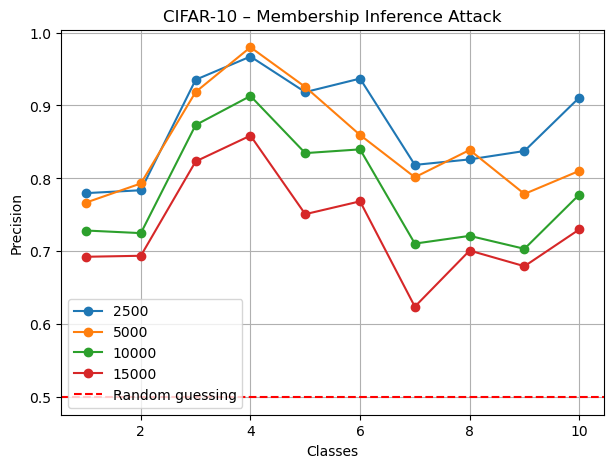

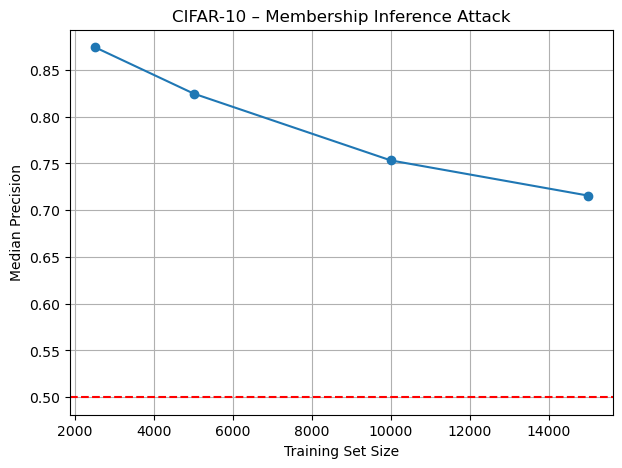

In [7]:
print("\nPlotting results")

plt.figure(figsize=(7,5))
for size in TRAIN_SIZES:
    p = all_precisions_per_size[size]
    plt.plot(np.arange(1, len(p)+1), p, marker='o', label=str(size))

plt.axhline(0.5, linestyle="--", color="red", label="Random guessing")
plt.xlabel("Classes")
plt.ylabel("Precision")
plt.title("CIFAR-10 – Membership Inference Attack")
plt.legend()
plt.grid(True)
plt.show()

sizes = sorted(median_per_size.keys())
medians = [median_per_size[s] for s in sizes]

plt.figure(figsize=(7,5))
plt.plot(sizes, medians, marker='o')
plt.axhline(0.5, linestyle="--", color="red")
plt.xlabel("Training Set Size")
plt.ylabel("Median Precision")
plt.title("CIFAR-10 – Membership Inference Attack")
plt.grid(True)
plt.show()